## 3D Resolution Estimation: FSC and DCR on Pollen Confocal Data

This notebook demonstrates directional (XY and Z) resolution estimation on a 3D confocal microscopy
image of pollen using two complementary methods:

- **SFSC** (Sectored Fourier Shell Correlation) — correlation-based, requires image splitting
- **DCR** (Decorrelation Analysis) — single-image, parameter-free

We compare results against the reference values from Koho et al. (2019) Figure 4b:
XY = 0.59 µm, Z = 3.91 µm.

**References:**
- Koho et al. (2019) "Fourier ring correlation simplifies image restoration in fluorescence microscopy", *Nature Communications* 10:3103.
- Descloux et al. (2019) "Parameter-free image resolution estimation based on decorrelation analysis", *Nature Methods* 16:918-924.

In [1]:
import nd2
import numpy as np
import matplotlib.pyplot as plt

from cubic.cuda import CUDAManager, ascupy, asnumpy, get_device
from cubic.image_utils import rescale_isotropic
from cubic.metrics.spectral import dcr_resolution, fsc_resolution
from cubic.metrics.spectral.dcr import dcr_curve, dcr_curve_3d_sectioned
from cubic.metrics.spectral.frc import (
    calculate_frc,
    preprocess_images,
    _calculate_fsc_sectioned_hist,
)
from cubic.metrics.spectral.plot import (
    plot_frc_curve,
    plot_dcr_curves,
    plot_dcr_sectors,
    plot_fsc_sectors,
)

USE_GPU = CUDAManager().num_gpus > 0
print(f"GPU available: {USE_GPU}")

GPU available: True


In [2]:
from pathlib import Path

import pooch

DATA_DIR = Path("../data")

# Pollen confocal stack (Koho et al. 2019, figshare)
pooch.retrieve(
    url="https://ndownloader.figshare.com/files/15203144",
    known_hash="sha256:5efae5cb356f352442fc3ab7c03fb0671f995e5b4606c63f59295774a8a483e1",
    fname="40x_TAGoff_z_galvo.nd2",
    path=DATA_DIR,
)

'/hpc/mydata/alex.kalinin/cubic/examples/data/40x_TAGoff_z_galvo.nd2'

### Load the pollen confocal image

40x confocal image of pollen grain acquired with a Nikon microscope.
Voxel spacing: Z = 0.250 µm, Y = X = 0.0777 µm (anisotropy factor z = 3.22).

In [3]:
spacing = [0.250, 0.0777, 0.0777]  # Z, Y, X in µm

with nd2.ND2File("../data/40x_TAGoff_z_galvo.nd2") as f:
    image = f.asarray()
    print(f"ND2 dimensions: {f.sizes}, dtype: {image.dtype}")
    dim_order = list(f.sizes.keys())
    c_axis = dim_order.index("C")
    image = np.take(image, 0, axis=c_axis).astype(np.float32)

print(f"Image shape (Z, Y, X): {image.shape}")
print(f"Spacing (Z, Y, X): {spacing} µm")
print(f"Anisotropy factor: {spacing[0] / spacing[1]:.2f}")

ND2 dimensions: {'Z': 181, 'C': 2, 'Y': 512, 'X': 512}, dtype: uint16
Image shape (Z, Y, X): (181, 512, 512)
Spacing (Z, Y, X): [0.25, 0.0777, 0.0777] µm
Anisotropy factor: 3.22


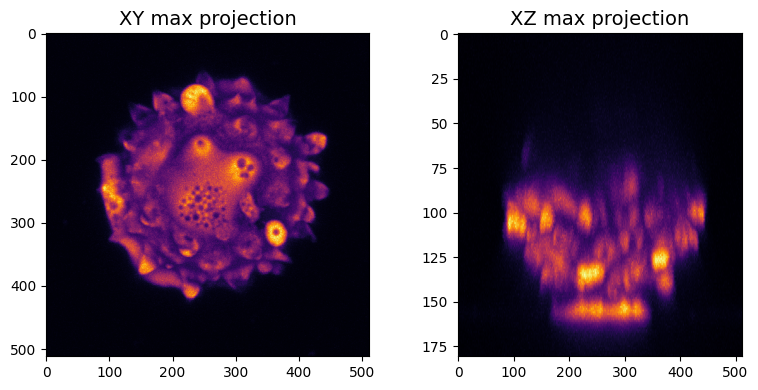

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(image.max(0), cmap="inferno")
axes[0].set_title("XY max projection", fontsize=14)
axes[1].imshow(image.max(1), cmap="inferno", aspect=spacing[0] / spacing[1])
axes[1].set_title("XZ max projection", fontsize=14)
plt.tight_layout()
plt.show()

In [5]:
image_gpu = ascupy(image) if USE_GPU else image
print(f"Device: {'GPU' if USE_GPU else 'CPU'}")

Device: GPU


In [6]:
# Extract middle slices for 2D comparison
mid_z = image.shape[0] // 2
mid_y = image.shape[1] // 2
xy_slice = image[mid_z]  # Middle XY slice
xz_slice = image[:, mid_y, :]  # Middle XZ slice

spacing_xy = [spacing[1], spacing[2]]  # [Y, X]
spacing_xz = [spacing[0], spacing[2]]  # [Z, X]

print(f"XY slice shape: {xy_slice.shape}, spacing: {spacing_xy}")
print(f"XZ slice shape: {xz_slice.shape}, spacing: {spacing_xz}")

XY slice shape: (512, 512), spacing: [0.0777, 0.0777]
XZ slice shape: (181, 512), spacing: [0.25, 0.0777]


### 3D FSC (Sectored Fourier Shell Correlation)

FSC compares two half-images obtained by checkerboard splitting. In single-image mode,
both forward and reverse splits are averaged to reduce variance (Koho et al. 2019).

Key parameters:
- `resample_isotropic=True`: Upsample Z to isotropic voxels before FSC
- `angle_delta=15`: 15° angular sectors matching the paper
- `resolution_threshold="one-bit"`: SNR-dependent threshold (paper methodology)

In [7]:
fsc_result = fsc_resolution(
    image_gpu,
    spacing=spacing,
    resample_isotropic=True,
    resample_order=1,
    angle_delta=15,
    bin_delta=1,
    resolution_threshold="one-bit",
    backend="hist",
)

print(f"FSC (one-bit threshold):")
print(f"  XY resolution: {fsc_result['xy']:.4f} µm")
print(f"  Z  resolution: {fsc_result['z']:.4f} µm")
print(f"  Z/XY ratio:    {fsc_result['z'] / fsc_result['xy']:.1f}")

FSC (one-bit threshold):
  XY resolution: 0.5836 µm
  Z  resolution: 4.3631 µm
  Z/XY ratio:    7.5


#### FSC correlation curves by angular sector

Each sector captures frequencies at a different polar angle from the Z axis.
The XY sector (θ ≈ 82°) measures lateral resolution; the Z sector (θ ≈ 8°) measures axial resolution.
Resolution is where the FSC curve crosses the one-bit threshold.

In [8]:
# Replicate the preprocessing that fsc_resolution does internally
iso_spacing = spacing[1]  # Y spacing
target_z_size = int(round(image_gpu.shape[0] * spacing[0] / iso_spacing))
if target_z_size % 2 != 0:
    target_z_size -= 1

image_iso = rescale_isotropic(
    image_gpu,
    spacing,
    downscale_xy=False,
    order=1,
    preserve_range=True,
    target_z_size=target_z_size,
).astype(np.float32)

even_shape = tuple(s - (s % 2) for s in image_iso.shape)
if image_iso.shape != even_shape:
    image_iso = image_iso[tuple(slice(0, es) for es in even_shape)]

print(f"Isotropic shape: {image_iso.shape}, spacing: {iso_spacing} µm")

# Checkerboard split + Hamming window
image1, image2 = preprocess_images(
    image_iso,
    None,
    zero_padding=False,
    disable_hamming=False,
    disable_3d_sum=False,
)

# Compute per-sector FSC data
fsc_data = _calculate_fsc_sectioned_hist(
    image1,
    image2,
    bin_delta=1,
    angle_delta=15,
    spacing=[iso_spacing] * 3,
)

print(f"Sectors: {sorted(fsc_data.keys())}")

Isotropic shape: (582, 512, 512), spacing: 0.0777 µm
Sectors: [8, 22, 38, 52, 68, 82]


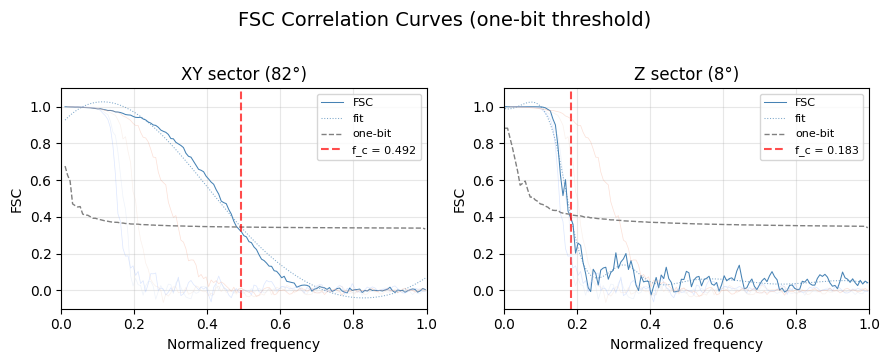

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
plot_fsc_sectors(fsc_data, iso_spacing, threshold="one-bit", axes=axes)
fig.suptitle("FSC Correlation Curves (one-bit threshold)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 2D FRC on XY and XZ slices

As a baseline comparison, we compute standard 2D FRC on individual slices extracted from the
volume: the middle XY slice (z = mid) for lateral resolution and the middle XZ slice (y = mid)
for axial resolution. This shows how single-slice estimates compare to the sectored 3D analysis.

In [10]:
frc_xy = calculate_frc(
    xy_slice,
    spacing=spacing_xy,
    curve_fit_type="smooth-spline",
)
frc_xz = calculate_frc(
    xz_slice,
    spacing=spacing_xz,
    curve_fit_type="smooth-spline",
)

print(f"2D FRC:")
print(f"  XY resolution: {frc_xy.resolution['resolution']:.4f} µm")
print(f"  XZ resolution: {frc_xz.resolution['resolution']:.4f} µm")

2D FRC:
  XY resolution: 0.8076 µm
  XZ resolution: 1.4377 µm


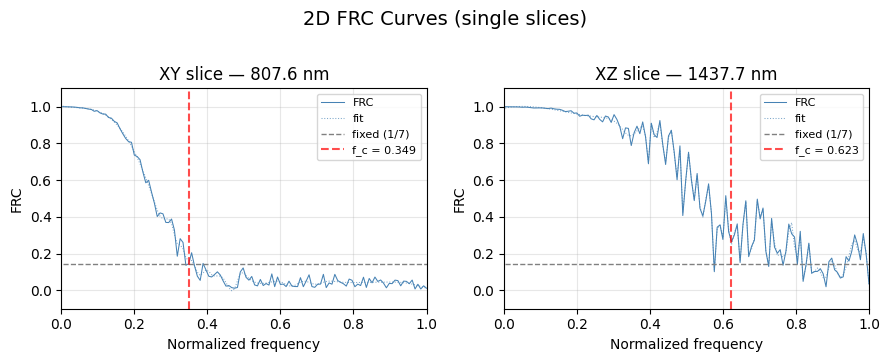

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
plot_frc_curve(frc_xy, axes[0])
axes[0].set_title(f"XY slice — {frc_xy.resolution['resolution'] * 1000:.1f} nm")
plot_frc_curve(frc_xz, axes[1])
axes[1].set_title(f"XZ slice — {frc_xz.resolution['resolution'] * 1000:.1f} nm")
fig.suptitle("2D FRC Curves (single slices)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 3D DCR (Decorrelation Analysis)

DCR estimates resolution from a single image by finding the highest frequency with
reproducible phase information. It uses angular sectoring to provide separate XY and Z
estimates, similar to FSC (Descloux et al. 2019).

Unlike FSC, DCR does not require isotropic resampling — it operates directly on the
anisotropic volume with physical spacing.

In [12]:
dcr_result = dcr_resolution(
    image_gpu,
    spacing=spacing,
    use_sectioned=True,
)

print(f"DCR (sectored 3D):")
print(f"  XY resolution: {dcr_result['xy']:.4f} µm")
print(f"  Z  resolution: {dcr_result['z']:.4f} µm")
print(f"  Z/XY ratio:    {dcr_result['z'] / dcr_result['xy']:.1f}")

DCR (sectored 3D):
  XY resolution: 1.0256 µm
  Z  resolution: 2.6197 µm
  Z/XY ratio:    2.6


#### DCR decorrelation curves by angular sector

Each curve corresponds to a different high-pass filter level (increasing sigma).
The resolution is determined by the highest-frequency peak across all curves.

In [13]:
# Compute sectored DCR curves using the library function
dcr_sector_data = dcr_curve_3d_sectioned(
    image_gpu,
    spacing=spacing,
    num_radii=100,
    num_highpass=10,
)

for sector in ["xy", "z"]:
    sd = dcr_sector_data[sector]
    print(
        f"{sector.upper()}: {len(sd['curves'])} curves, "
        f"k_max = {sd['k_max']:.4f} µm⁻¹, "
        f"resolution = {sd['resolution']:.4f} µm"
    )

XY: 21 curves, k_max = 6.4350 µm⁻¹, resolution = 1.0256 µm
Z: 21 curves, k_max = 1.9890 µm⁻¹, resolution = 2.6197 µm


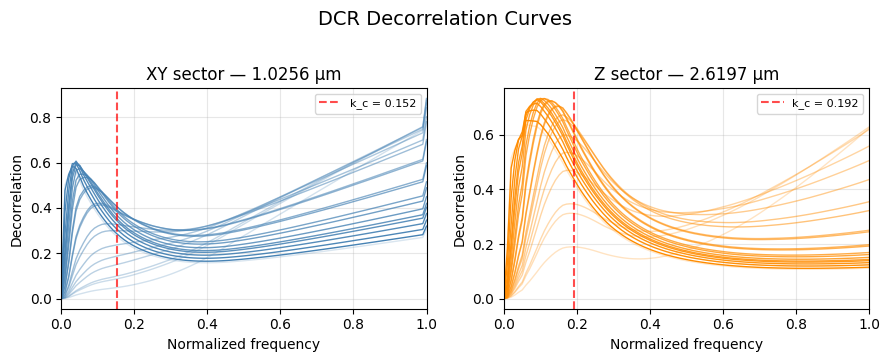

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
plot_dcr_sectors(dcr_sector_data, axes=axes)
fig.suptitle("DCR Decorrelation Curves", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 2D DCR on XY and XZ slices

Same slice-based baseline as 2D FRC above, but using the decorrelation method. DCR operates
on a single image without splitting, so it provides an independent check of the 2D resolution
estimates.

In [15]:
dcr_xy_res, dcr_xy_radii, dcr_xy_curves, dcr_xy_peaks = dcr_curve(
    xy_slice, spacing=spacing_xy
)
dcr_xz_res, dcr_xz_radii, dcr_xz_curves, dcr_xz_peaks = dcr_curve(
    xz_slice, spacing=spacing_xz
)

print(f"2D DCR:")
print(f"  XY resolution: {dcr_xy_res:.4f} µm")
print(f"  XZ resolution: {dcr_xz_res:.4f} µm")

2D DCR:
  XY resolution: 0.9212 µm
  XZ resolution: 1.8662 µm


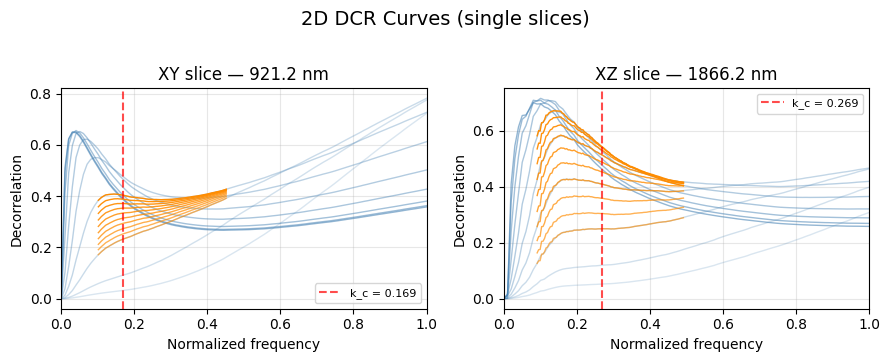

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
plot_dcr_curves(dcr_xy_radii, dcr_xy_curves, dcr_xy_peaks, axes[0])
axes[0].set_title(f"XY slice — {dcr_xy_res * 1000:.1f} nm")
plot_dcr_curves(dcr_xz_radii, dcr_xz_curves, dcr_xz_peaks, axes[1])
axes[1].set_title(f"XZ slice — {dcr_xz_res * 1000:.1f} nm")
fig.suptitle("2D DCR Curves (single slices)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Comparison

Compare all estimates against the Koho et al. 2019 reference values for this pollen image.

In [17]:
paper_xy, paper_z = 0.59, 3.91

frc_xy_res = frc_xy.resolution["resolution"]
frc_xz_res = frc_xz.resolution["resolution"]

methods = {
    "Koho et al.": {"xy": paper_xy, "z": paper_z},
    "FSC (3D sectored)": fsc_result,
    "FRC (2D slices)": {"xy": frc_xy_res, "z": frc_xz_res},
    "DCR (3D sectored)": dcr_result,
    "DCR (2D slices)": {"xy": dcr_xy_res, "z": dcr_xz_res},
}

print(f"{'Method':<22} {'XY (µm)':<12} {'Z (µm)':<12} {'Z/XY':<8}")
print("-" * 54)
for name, res in methods.items():
    xy, z = res["xy"], res["z"]
    ratio = z / xy if xy > 0 else float("nan")
    print(f"{name:<22} {xy:<12.4f} {z:<12.4f} {ratio:<8.1f}")

Method                 XY (µm)      Z (µm)       Z/XY    
------------------------------------------------------
Koho et al.            0.5900       3.9100       6.6     
FSC (3D sectored)      0.5836       4.3631       7.5     
FRC (2D slices)        0.8076       1.4377       1.8     
DCR (3D sectored)      1.0256       2.6197       2.6     
DCR (2D slices)        0.9212       1.8662       2.0     
